# Carga de datos

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, acf
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('deep')

In [6]:
df = pd.read_csv('viajes_ya.csv', parse_dates=['week'])
df = df.sort_values('week').reset_index(drop=True)

In [7]:
CANALES = ['search_spend', 'social_spend', 'tv_spend', 'display_spend']
NOMBRES = {'search_spend': 'Motores de búsqueda',
           'social_spend': 'Redes sociales',
           'tv_spend': 'Televisión',
           'display_spend': 'Exteriores'}

# Variables derivadas de calendario
df['year']  = df['week'].dt.year
df['month'] = df['week'].dt.month
df['woy']   = df['week'].dt.isocalendar().week.astype(int)
df['t']     = np.arange(len(df))          # tendencia
df['total_spend'] = df[CANALES].sum(axis=1)

print(f"Periodo: {df.week.min().date()} a {df.week.max().date()}  ({len(df)} semanas)")
print(f"Nulos: {df.isna().sum().sum()} | Semanas duplicadas: {df.week.duplicated().sum()}")
df.head()

Periodo: 2023-01-01 a 2025-12-21  (156 semanas)
Nulos: 0 | Semanas duplicadas: 0


,week,revenue,search_spend,social_spend,tv_spend,display_spend,promotion,discount_pct,holiday,year,month,woy,t,total_spend
0,2023-01-01,"712,623.16","38,000.08","26,513.74","62,193.70","17,959.05",1,0.10,1,2023,1,52,0,"144,666.57"
1,2023-01-08,"682,516.92","32,872.22","20,731.24","91,198.93","14,477.60",0,0.00,1,2023,1,1,1,"159,279.99"
2,2023-01-15,"563,435.64","21,731.56","24,391.38",132.64,"12,717.09",0,0.00,0,2023,1,2,2,"58,972.67"
3,2023-01-22,"570,764.32","22,523.08","21,518.57","7,944.68","12,558.74",0,0.00,0,2023,1,3,3,"64,545.07"
4,2023-01-29,"603,820.13","21,082.07","14,929.85","62,613.73","7,430.73",0,0.00,0,2023,1,4,4,"106,056.38"


# Estadísticas descriptivas

In [8]:
desc = df[['revenue'] + CANALES + ['discount_pct']].describe().T
desc['CV'] = desc['std'] / desc['mean']          # coeficiente de variación
display(desc[['mean','std','min','50%','max','CV']].round(2))

print("\n--- Variables binarias ---")
print(f"Semanas con promoción: {df.promotion.sum()} ({df.promotion.mean():.1%})")
print(f"Semanas con feriado:   {df.holiday.sum()} ({df.holiday.mean():.1%})")

print("\n--- Inversión total por canal (3 años) ---")
tot = df[CANALES].sum()
resumen = pd.DataFrame({
    'Inversión total': tot,
    'Share %': (tot / tot.sum() * 100).round(1),
    'Promedio semanal': df[CANALES].mean()
})
resumen.index = [NOMBRES[c] for c in resumen.index]
display(resumen.round(2))

print(f"\nRevenue total: ${df.revenue.sum():,.0f}")
print(f"Inversión total: ${df.total_spend.sum():,.0f}")
print(f"ROAS 'naive' (revenue total / spend total): {df.revenue.sum()/df.total_spend.sum():.2f}")
print("  ^ OJO: este número NO es el ROAS real. Incluye todo el revenue base,")
print("    o sea las ventas que ocurrirían aunque no se invirtiera un centavo.")

,mean,std,min,50%,max,CV
revenue,"579,874.77","74,397.04","423,749.46","567,750.00","858,195.10",0.13
search_spend,"25,428.00","6,189.65","11,442.03","25,039.12","41,126.55",0.24
social_spend,"18,378.18","3,569.23","9,256.10","18,195.93","29,709.57",0.19
tv_spend,"16,958.27","27,148.81",132.64,"5,097.24","96,595.02",1.60
display_spend,"10,916.06","2,572.85","3,248.25","10,836.70","18,691.86",0.24
discount_pct,0.01,0.05,0.00,0.00,0.30,3.59



--- Variables binarias ---
Semanas con promoción: 13 (8.3%)
Semanas con feriado:   18 (11.5%)

--- Inversión total por canal (3 años) ---


,Inversión total,Share %,Promedio semanal
Motores de búsqueda,"3,966,768.59",35.50,"25,428.00"
Redes sociales,"2,866,996.18",25.60,"18,378.18"
Televisión,"2,645,490.21",23.70,"16,958.27"
Exteriores,"1,702,905.73",15.20,"10,916.06"



Revenue total: $90,460,464
Inversión total: $11,182,161
ROAS 'naive' (revenue total / spend total): 8.09
  ^ OJO: este número NO es el ROAS real. Incluye todo el revenue base,
    o sea las ventas que ocurrirían aunque no se invirtiera un centavo.


# Serie de tiempo del revenue

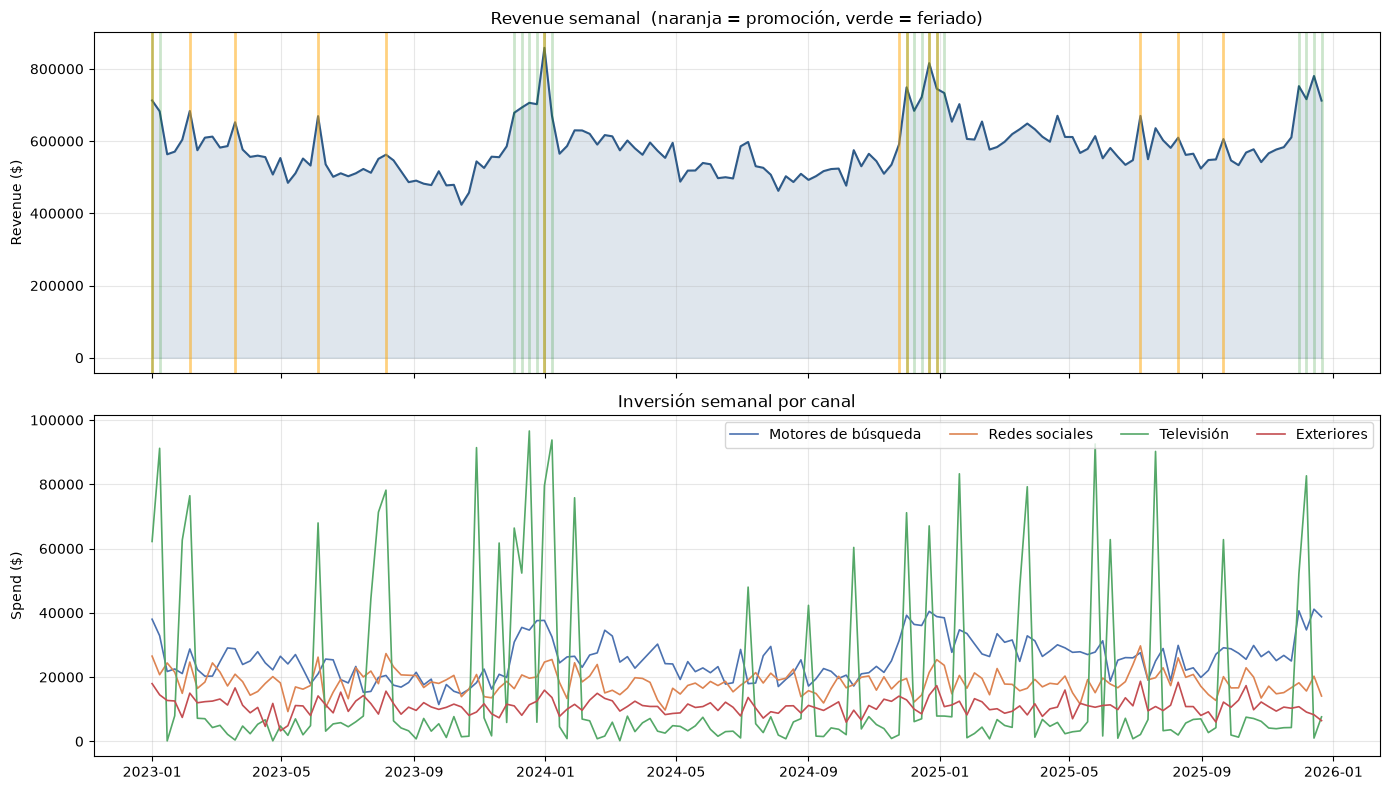

In [9]:
fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax[0].plot(df.week, df.revenue, color='#2E5A88', lw=1.5)
ax[0].fill_between(df.week, df.revenue, alpha=0.15, color='#2E5A88')
# marcar promociones y feriados
for _, r in df[df.promotion == 1].iterrows():
    ax[0].axvline(r.week, color='orange', alpha=0.5, lw=2)
for _, r in df[df.holiday == 1].iterrows():
    ax[0].axvline(r.week, color='green', alpha=0.2, lw=2)
ax[0].set_title('Revenue semanal  (naranja = promoción, verde = feriado)')
ax[0].set_ylabel('Revenue ($)')

for c in CANALES:
    ax[1].plot(df.week, df[c], label=NOMBRES[c], lw=1.2)
ax[1].set_title('Inversión semanal por canal')
ax[1].set_ylabel('Spend ($)')
ax[1].legend(ncol=4)
plt.tight_layout(); plt.show()

# Estacionalidad

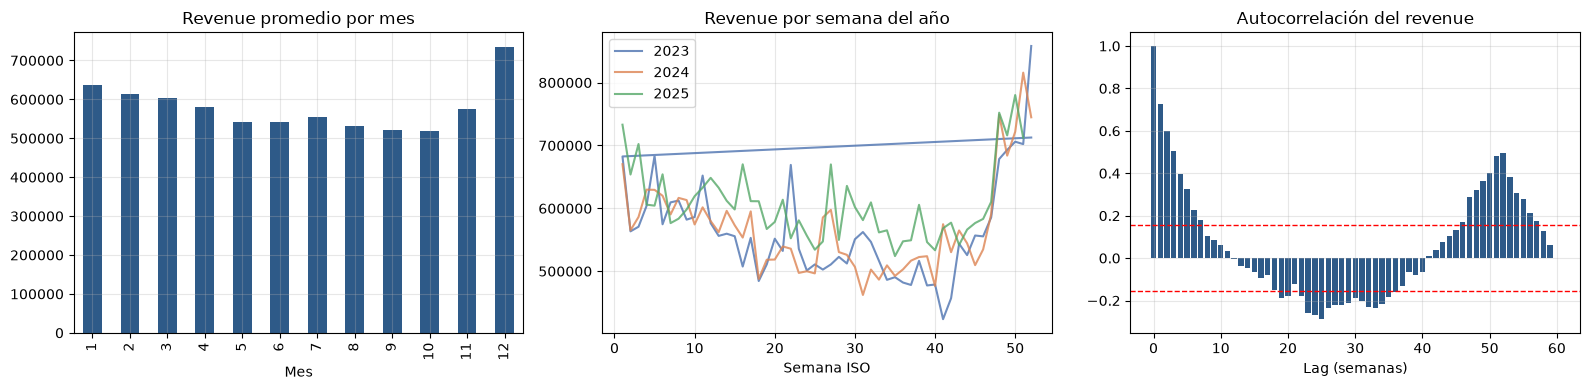

Autocorrelación lag 1:  0.740
Autocorrelación lag 52: 0.753   <- estacionalidad anual


In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

df.groupby('month').revenue.mean().plot(kind='bar', ax=ax[0], color='#2E5A88')
ax[0].set_title('Revenue promedio por mes'); ax[0].set_xlabel('Mes')

for y in sorted(df.year.unique()):
    sub = df[df.year == y]
    ax[1].plot(sub.woy, sub.revenue, label=str(y), alpha=0.8)
ax[1].set_title('Revenue por semana del año'); ax[1].set_xlabel('Semana ISO'); ax[1].legend()

lags = 60
ac = acf(df.revenue, nlags=lags)
ax[2].bar(range(lags+1), ac, color='#2E5A88')
ax[2].axhline(1.96/np.sqrt(len(df)), ls='--', color='red', lw=1)
ax[2].axhline(-1.96/np.sqrt(len(df)), ls='--', color='red', lw=1)
ax[2].set_title('Autocorrelación del revenue'); ax[2].set_xlabel('Lag (semanas)')
plt.tight_layout(); plt.show()

print(f"Autocorrelación lag 1:  {df.revenue.autocorr(1):.3f}")
print(f"Autocorrelación lag 52: {df.revenue.autocorr(52):.3f}   <- estacionalidad anual")

# Correlaciones y multicolinealidad

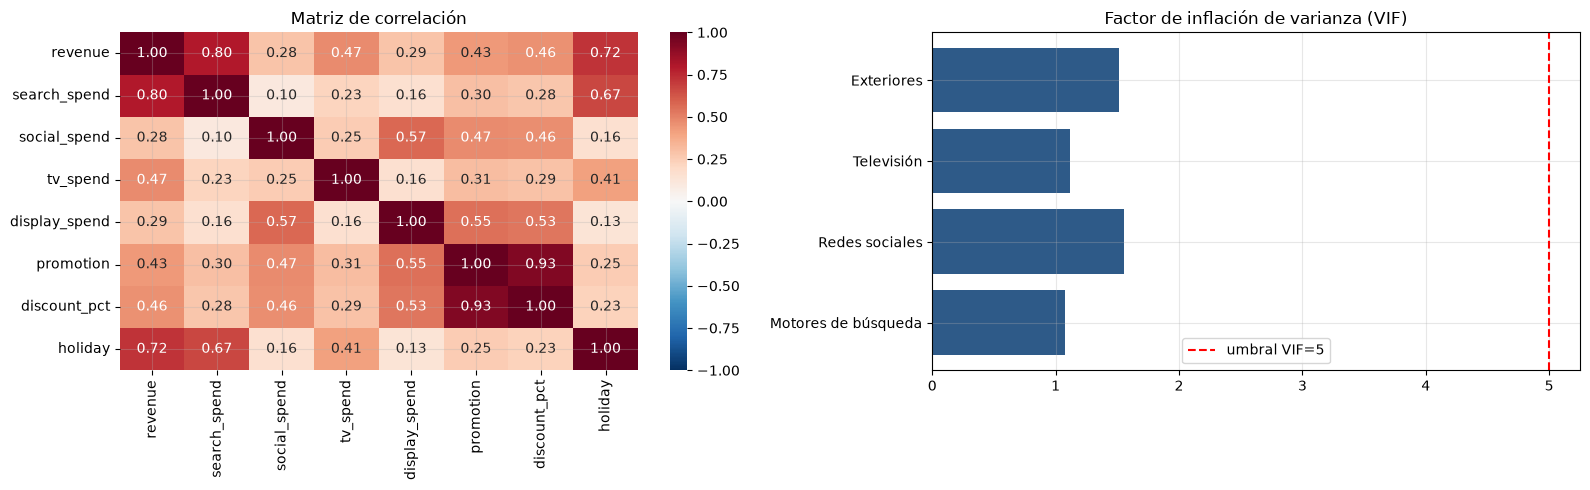

,Variable,VIF
1,search_spend,1.07
2,social_spend,1.55
3,tv_spend,1.12
4,display_spend,1.51


In [11]:
cols = ['revenue'] + CANALES + ['promotion', 'discount_pct', 'holiday']
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax[0])
ax[0].set_title('Matriz de correlación')

X = sm.add_constant(df[CANALES])
vif = pd.DataFrame({'Variable': X.columns,
                    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
vif = vif[vif.Variable != 'const']
ax[1].barh([NOMBRES[v] for v in vif.Variable], vif.VIF, color='#2E5A88')
ax[1].axvline(5, ls='--', color='red', label='umbral VIF=5')
ax[1].set_title('Factor de inflación de varianza (VIF)'); ax[1].legend()
plt.tight_layout(); plt.show()

display(vif.round(2))

# Patrón de TV (flighting) y efecto de promo/feriado

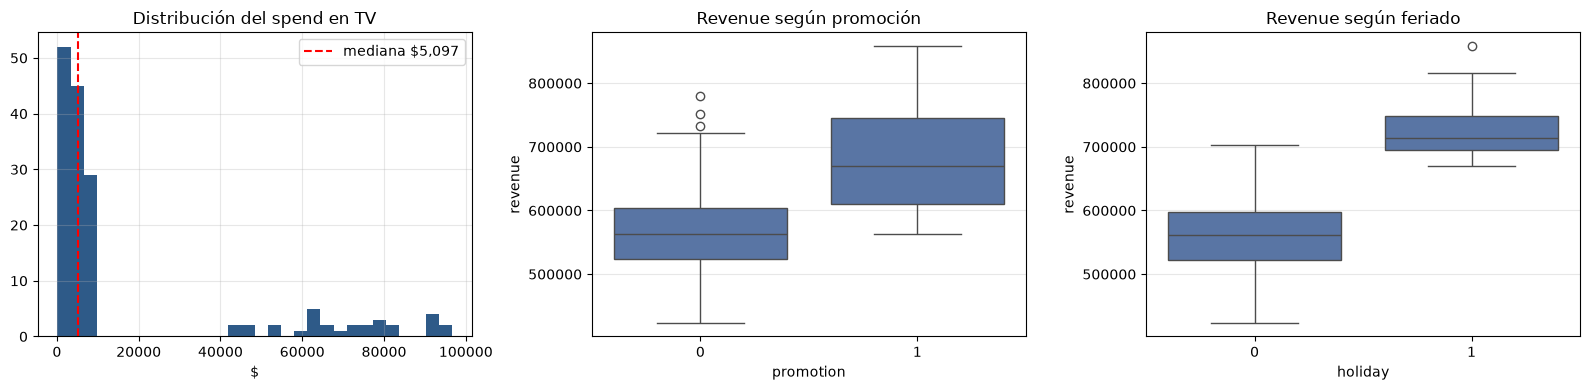

TV — percentiles:
count      156.00
mean    16,958.00
std     27,149.00
min        133.00
10%      1,239.00
25%      2,674.00
50%      5,097.00
75%      7,619.00
90%     67,514.00
max     96,595.00
Name: tv_spend, dtype: float64

Semanas con TV < $1,000: 12 de 156

Lift observado (bruto, sin controlar nada):
  Promoción: +20.4%
  Feriado:   +30.0%


In [12]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

ax[0].hist(df.tv_spend, bins=30, color='#2E5A88')
ax[0].set_title('Distribución del spend en TV'); ax[0].set_xlabel('$')
ax[0].axvline(df.tv_spend.median(), color='red', ls='--', label=f'mediana ${df.tv_spend.median():,.0f}')
ax[0].legend()

sns.boxplot(data=df, x='promotion', y='revenue', ax=ax[1])
ax[1].set_title('Revenue según promoción')

sns.boxplot(data=df, x='holiday', y='revenue', ax=ax[2])
ax[2].set_title('Revenue según feriado')
plt.tight_layout(); plt.show()

print("TV — percentiles:")
print(df.tv_spend.describe(percentiles=[.1,.25,.5,.75,.9]).round(0))
print(f"\nSemanas con TV < $1,000: {(df.tv_spend<1000).sum()} de {len(df)}")
print("\nLift observado (bruto, sin controlar nada):")
print(f"  Promoción: {df[df.promotion==1].revenue.mean()/df[df.promotion==0].revenue.mean()-1:+.1%}")
print(f"  Feriado:   {df[df.holiday==1].revenue.mean()/df[df.holiday==0].revenue.mean()-1:+.1%}")

# Diagnóstico de estacionariedad

In [13]:
adf = adfuller(df.revenue)
print(f"ADF revenue: estadístico={adf[0]:.3f}, p-value={adf[1]:.4f}")
print("Serie estacionaria" if adf[1] < 0.05 else "Serie NO estacionaria")

print("\n--- Correlación de cada canal con las variables de calendario ---")
print(df[CANALES + ['holiday','promotion']].corr().loc[CANALES, ['holiday','promotion']].round(3))

ADF revenue: estadístico=-3.509, p-value=0.0078
Serie estacionaria

--- Correlación de cada canal con las variables de calendario ---
               holiday  promotion
search_spend      0.67       0.30
social_spend      0.16       0.47
tv_spend          0.41       0.31
display_spend     0.13       0.55


C:\Users\caste\AppData\Local\Temp\ipykernel_15492\3693011671.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = adfuller(df.revenue)


## Análisis exploratorio de la data

El conjunto de datos contiene 156 semanas continuas, desde enero de 2023 hasta diciembre de 2025, sin valores nulos ni registros duplicados. El revenue semanal promedio es de $579,875, con un coeficiente de variación de 0.13. Sin embargo, oscila entre $423,749 y $858,195, lo cual refleja un nivel base relativamente estable acompañado de incrementos concentrados en momentos específicos del calendario. Search concentra el 35.5% del presupuesto; social, el 25.6%; TV, el 23.7%; y exteriores, el 15.2%.

La forma en que se distribuye el gasto resulta más relevante que su monto total. Search, social y exteriores presentan coeficientes de variación de entre 0.19 y 0.24, lo que indica una inversión relativamente continua. En cambio, TV tiene un coeficiente de variación de 1.60 y una distribución bimodal: durante 125 semanas, la inversión fue inferior a $10,000, mientras que en aproximadamente 25 semanas se ubicó entre $45,000 y $96,595, casi sin valores intermedios. Esto demuestra que TV no escala gradualmente, sino que se activa mediante campañas puntuales. Por ello, existen pocas observaciones del canal en funcionamiento y la estimación de su efecto será menos precisa.

La estacionalidad es marcada: diciembre registra un revenue promedio de $735,470, frente a $519,088 en octubre. Además, las curvas correspondientes a las semanas ISO de los tres años presentan patrones muy similares. La función de autocorrelación (ACF) no disminuye de forma continua, sino que muestra un comportamiento ondulatorio y vuelve a elevarse hasta aproximadamente 0.5 alrededor del rezago 52, lo que evidencia un ciclo anual. La autocorrelación en el rezago 1 es de 0.740, por lo que podrían presentarse residuos correlacionados. La prueba ADF descarta la presencia de una raíz unitaria; sin embargo, esto no implica que no exista estacionalidad, sino únicamente que no es necesario diferenciar la serie para hacerla estacionaria.

El principal hallazgo es la endogeneidad en la asignación del presupuesto. Revenue y search presentan una correlación de 0.80, la más alta del conjunto. No obstante, search también se correlaciona en 0.67 con holiday, mientras que holiday se correlaciona en 0.72 con revenue. Esto indica que la temporada alta explica simultáneamente el aumento del revenue y de la inversión en búsqueda. Exteriores presenta un patrón similar, ya que se correlaciona más con promotion que con revenue. Los factores de inflación de la varianza (VIF) de los canales se encuentran por debajo de 1.6, por lo que la multicolinealidad entre medios no constituye la principal dificultad. El problema central es la posible omisión de variables relevantes, debido a que la inversión en los canales responde a la demanda esperada. Por esta misma razón, el ROAS agregado de 8.099 no representa adecuadamente el efecto de la publicidad, pues atribuye a los medios todas las ventas, incluido el revenue base que habría existido sin inversión publicitaria.

# Modelo Inicial

In [14]:
y  = df['revenue']
X1 = sm.add_constant(df[CANALES])

modelo1 = sm.OLS(y, X1).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.747
Method:                 Least Squares   F-statistic:                     115.3
Date:                Tue, 01 Sep 2026   Prob (F-statistic):           7.29e-45
Time:                        21:03:13   Log-Likelihood:                -1861.5
No. Observations:                 156   AIC:                             3733.
Df Residuals:                     151   BIC:                             3748.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          2.877e+05   1.99e+04     14.438

# Interpretación de coeficientes

In [15]:
coef = pd.DataFrame({
    'Canal': [NOMBRES[c] for c in CANALES],
    'Coeficiente': [modelo1.params[c] for c in CANALES],
    'p-value': [modelo1.pvalues[c] for c in CANALES],
    'IC 2.5%': [modelo1.conf_int().loc[c, 0] for c in CANALES],
    'IC 97.5%': [modelo1.conf_int().loc[c, 1] for c in CANALES],
    'Spend promedio': [df[c].mean() for c in CANALES],
})
coef['Contribución $'] = coef['Coeficiente'] * coef['Spend promedio']
coef['Contribución %'] = coef['Contribución $'] / y.mean() * 100
coef['Significativo'] = np.where(coef['p-value'] < 0.05, 'Sí', 'No')
display(coef.round(2))

base = modelo1.params['const']
print(f"\nIntercepto (revenue base implícito): ${base:,.0f}  =  {base/y.mean():.1%} del revenue promedio")
print(f"Contribución total de medios: {coef['Contribución %'].sum():.1f}%")
print("\nLectura literal de los coeficientes:")
for _, r in coef.iterrows():
    print(f"  {r['Canal']}: cada $1 invertido se asocia a ${r['Coeficiente']:.2f} de revenue")

,Canal,Coeficiente,p-value,IC 2.5%,IC 97.5%,Spend promedio,Contribución $,Contribución %,Significativo
0,Motores de búsqueda,8.62,0.00,7.62,9.61,"25,428.00","219,084.01",37.78,Sí
1,Redes sociales,2.00,0.06,-0.08,4.07,"18,378.18","36,738.82",6.34,No
2,Televisión,0.76,0.00,0.52,0.99,"16,958.27","12,815.13",2.21,Sí
3,Exteriores,2.16,0.14,-0.68,5.00,"10,916.06","23,547.51",4.06,No



Intercepto (revenue base implícito): $287,689  =  49.6% del revenue promedio
Contribución total de medios: 50.4%

Lectura literal de los coeficientes:
  Motores de búsqueda: cada $1 invertido se asocia a $8.62 de revenue
  Redes sociales: cada $1 invertido se asocia a $2.00 de revenue
  Televisión: cada $1 invertido se asocia a $0.76 de revenue
  Exteriores: cada $1 invertido se asocia a $2.16 de revenue


# Diagnósticos

Durbin-Watson: 1.470   (2.0 = sin autocorrelación)
Breusch-Pagan p-value: 0.3036

Ljung-Box (autocorrelación de residuos):


,lb_stat,lb_pvalue
1,10.49,0.00
4,12.52,0.01
12,23.14,0.03


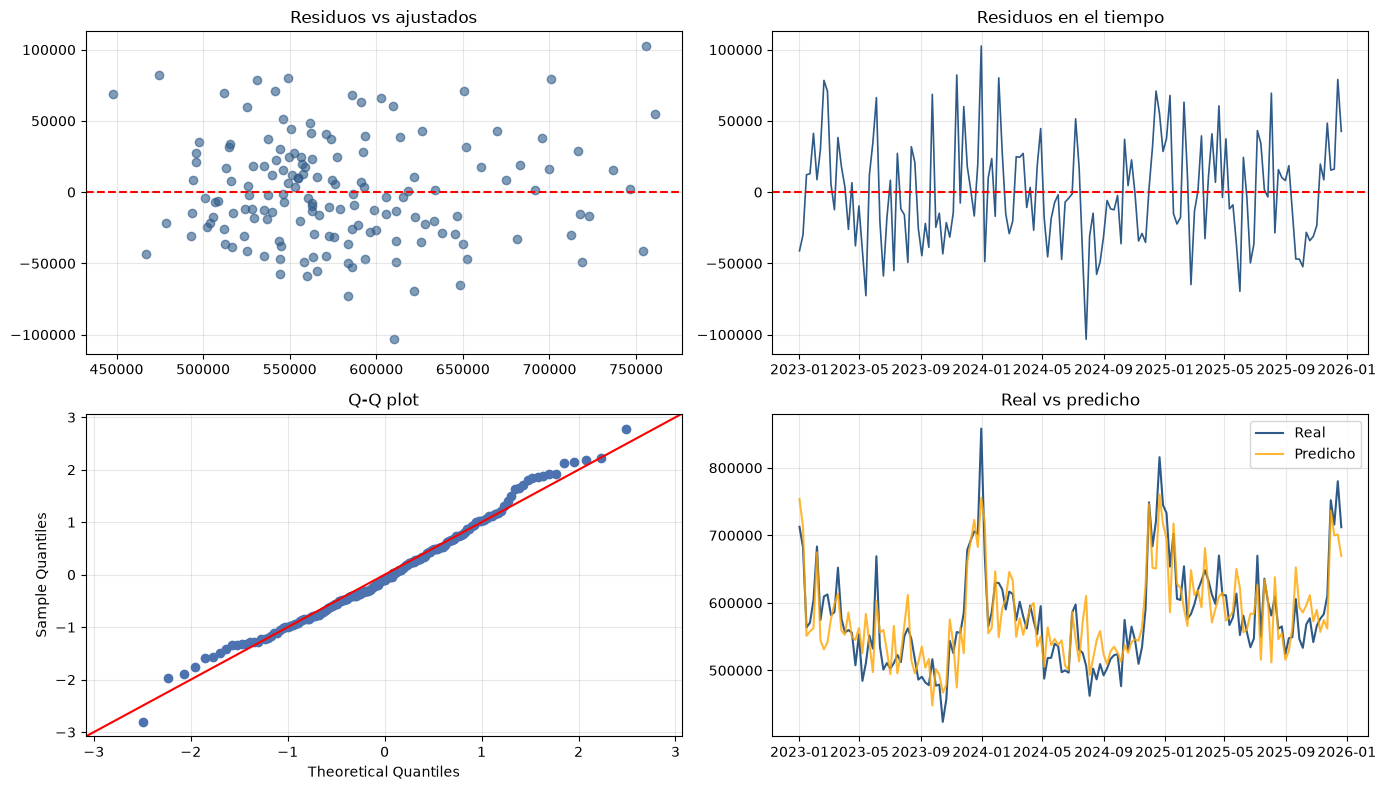

In [16]:
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

resid = modelo1.resid
fitted = modelo1.fittedvalues

print(f"Durbin-Watson: {durbin_watson(resid):.3f}   (2.0 = sin autocorrelación)")
print(f"Breusch-Pagan p-value: {het_breuschpagan(resid, X1)[1]:.4f}")
print("\nLjung-Box (autocorrelación de residuos):")
display(acorr_ljungbox(resid, lags=[1, 4, 12], return_df=True).round(4))

fig, ax = plt.subplots(2, 2, figsize=(14, 8))
ax[0,0].scatter(fitted, resid, alpha=0.6, color='#2E5A88')
ax[0,0].axhline(0, color='red', ls='--'); ax[0,0].set_title('Residuos vs ajustados')

ax[0,1].plot(df.week, resid, color='#2E5A88', lw=1.2)
ax[0,1].axhline(0, color='red', ls='--'); ax[0,1].set_title('Residuos en el tiempo')

sm.qqplot(resid, line='45', fit=True, ax=ax[1,0]); ax[1,0].set_title('Q-Q plot')

ax[1,1].plot(df.week, y, label='Real', color='#2E5A88', lw=1.5)
ax[1,1].plot(df.week, fitted, label='Predicho', color='orange', lw=1.5, alpha=0.8)
ax[1,1].set_title('Real vs predicho'); ax[1,1].legend()
plt.tight_layout(); plt.show()

# Evidencia del sesgo por variable omitida

In [17]:
# Prueba directa: qué pasa con los coeficientes al agregar los controles de calendario
X_ctrl = sm.add_constant(df[CANALES + ['holiday', 'discount_pct']])
modelo_ctrl = sm.OLS(y, X_ctrl).fit()

comp = pd.DataFrame({
    'Canal': [NOMBRES[c] for c in CANALES],
    'Sin controles': [modelo1.params[c] for c in CANALES],
    'Con holiday + discount': [modelo_ctrl.params[c] for c in CANALES],
})
comp['Cambio %'] = (comp['Con holiday + discount'] / comp['Sin controles'] - 1) * 100
display(comp.round(2))

print(f"R² : {modelo1.rsquared:.3f}  ->  {modelo_ctrl.rsquared:.3f}")
print(f"Intercepto: ${modelo1.params['const']:,.0f}  ->  ${modelo_ctrl.params['const']:,.0f}")
print("\nTodos los coeficientes de medios CAEN al agregar apenas dos controles.")
print("Eso confirma que el modelo inicial les estaba atribuyendo efecto del calendario.")

,Canal,Sin controles,Con holiday + discount,Cambio %
0,Motores de búsqueda,8.62,6.65,-22.84
1,Redes sociales,2.00,1.13,-43.59
2,Televisión,0.76,0.53,-30.27
3,Exteriores,2.16,0.64,-70.38


R² : 0.753  ->  0.792
Intercepto: $287,689  ->  $364,850

Todos los coeficientes de medios CAEN al agregar apenas dos controles.
Eso confirma que el modelo inicial les estaba atribuyendo efecto del calendario.


## 2. Modelo inicial

Se estimó una regresión lineal con revenue como variable dependiente y los cuatro 
montos de inversión como regresoras. Vale una precisión sobre el enunciado: revenue es 
la dependiente, porque es lo que se busca explicar, y los spend las independientes. El 
modelo alcanza un R² de 0.753. Los coeficientes se leen como el revenue asociado a 
cada dólar invertido: $8.62 en buscadores, $2.16 en exteriores, $2.00 en redes 
sociales y $0.76 en televisión. Solo search y TV resultan significativos; los 
intervalos de social y display cruzan el cero, así que el modelo no logra distinguir 
su efecto de cero. El intercepto de $287,689 implica que apenas la mitad del revenue 
sería base, cifra implausible para una agencia establecida con marca y clientes 
recurrentes.

El problema de fondo es el sesgo por variable omitida que ya anticipaba el análisis 
exploratorio. Un retorno sostenido de 8.6x en buscadores no es creíble: si lo fuera, 
lo racional sería concentrar todo el presupuesto ahí. La prueba es directa. Al agregar 
solo holiday y discount_pct como controles, todos los coeficientes caen, search 23%, 
TV 30%, social 44% y exteriores 70%, mientras el intercepto sube a $364,850. Que dos 
variables muevan tanto las estimaciones confirma que el modelo estaba acreditando a la 
publicidad ventas que corresponden al calendario. Los residuos además están 
autocorrelacionados (Durbin-Watson de 1.470) y su gráfica en el tiempo muestra rachas 
de error del mismo signo, señal de que el modelo falla sistemáticamente en las mismas 
épocas del año.

No todo falla, y conviene decirlo: los tests de Breusch-Pagan y Jarque-Bera no 
detectan problemas de heterocedasticidad ni de normalidad. Las limitaciones que quedan 
son de forma. El modelo es lineal, o sea asume que el retorno por dólar es constante 
para siempre e ignora que los canales se saturan. Tampoco contempla que la publicidad 
sigue teniendo efecto en las semanas posteriores a su emisión, algo especialmente 
relevante para televisión, cuya inversión va en ráfagas. En conclusión, el modelo no 
es apropiado para decidir presupuesto: sirve como línea base y como diagnóstico, pero 
sobrestima de forma sistemática el aporte de los medios.